# Email Spam Filter

## Project Objective

This project analyzes email subject lines and decides if it is spam or ham (not spam emails).

The goal is to generate an accurate model that can detect if an email is spam or ham. 


# Data Loading

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
origional_df = pd.read_csv("emails.csv")
origional_df.dtypes

text    object
spam     int64
dtype: object

# Data Cleaning

In [3]:
origional_df.head

<bound method NDFrame.head of                                                    text  spam
0     Subject: naturally irresistible your corporate...     1
1     Subject: the stock trading gunslinger  fanny i...     1
2     Subject: unbelievable new homes made easy  im ...     1
3     Subject: 4 color printing special  request add...     1
4     Subject: do not have money , get software cds ...     1
...                                                 ...   ...
5723  Subject: re : research and development charges...     0
5724  Subject: re : receipts from visit  jim ,  than...     0
5725  Subject: re : enron case study update  wow ! a...     0
5726  Subject: re : interest  david ,  please , call...     0
5727  Subject: news : aurora 5 . 2 update  aurora ve...     0

[5728 rows x 2 columns]>

This dataset hold emails that are encoded, 1 being spam and 0 being ham (a legitamit email)

In [4]:
origional_df.drop_duplicates(inplace=True)
print(f"Duplicate rows after cleaning: {origional_df.duplicated().sum()}")

Duplicate rows after cleaning: 0


In [5]:
missing_values = origional_df.isnull().sum()
print("Missing values before handling:")
print (missing_values)

Missing values before handling:
text    0
spam    0
dtype: int64


There are no duplicated rows and no missing values

# Unigram Modeling

In [6]:
# Split into training (80%) and test (20%) datasets
train_df, test_df = train_test_split(origional_df, test_size=0.2, random_state=42)

# Save the datasets
train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

print("Training and test datasets saved.")

Training and test datasets saved.


In [7]:
# Define the independent and dependent variables
X_train = train_df['text']
y_train = train_df['spam']
X_test = test_df['text']
y_test = test_df['spam']


In [8]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

Above we turned to words of the subject in the email into what a computer can understand better. To do this we used TF-IDF Vectorization, this basically takes words and turns it into numerical values baced on the importance of the word. 

In [9]:
model = LogisticRegression()
model.fit(X_train_vec, y_train)

LogisticRegression()

In [10]:
y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       843
           1       0.99      0.94      0.96       296

    accuracy                           0.98      1139
   macro avg       0.98      0.97      0.97      1139
weighted avg       0.98      0.98      0.98      1139



In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9806848112379281


In [12]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_spam_words = sorted(zip(coefficients, feature_names), reverse=True)[:20]
top_ham_words = sorted(zip(coefficients, feature_names))[:20]

In [13]:
print("Top Spam Words:")
for coef, word in top_spam_words:
    print(f"{word}: {coef:.3f}")

print("\nTop Ham Words:")
for coef, word in top_ham_words:
    print(f"{word}: {coef:.3f}")

Top Spam Words:
click: 3.213
money: 2.800
software: 2.634
life: 2.573
http: 2.382
online: 2.374
2005: 2.364
free: 2.346
save: 2.299
viagra: 2.258
account: 2.106
website: 2.101
man: 1.956
adobe: 1.869
company: 1.760
sex: 1.739
net: 1.704
love: 1.634
95: 1.512
site: 1.460

Top Ham Words:
enron: -5.489
vince: -5.223
2000: -2.963
ect: -2.830
thanks: -2.677
research: -2.645
kaminski: -2.214
energy: -2.142
model: -2.094
2001: -2.053
risk: -1.889
meeting: -1.843
attached: -1.709
713: -1.681
edu: -1.629
conference: -1.627
houston: -1.612
group: -1.591
power: -1.495
pm: -1.483


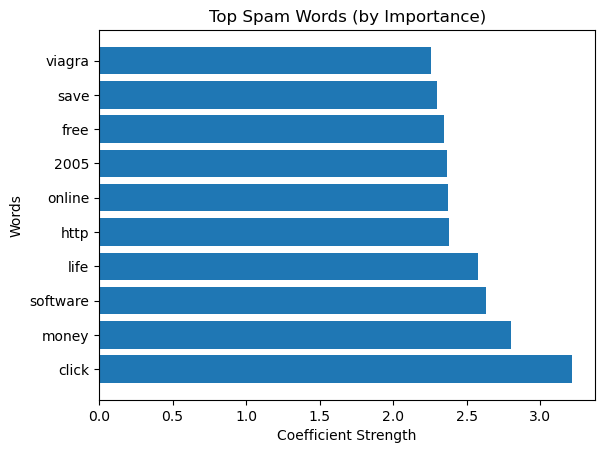

In [14]:
# Get top 10 spam words
top_words = [word for coef, word in top_spam_words[:10]]
top_values = [abs(coef) for coef, word in top_spam_words[:10]]

plt.figure()
plt.barh(top_words, top_values)
plt.title("Top Spam Words (by Importance)")
plt.xlabel("Coefficient Strength")
plt.ylabel("Words")
plt.show()

At the moment this looks at unigrams, single words. When it comes to spam, contect is important a fiar amount of times so we will rerun the model with different amount of word combinations (1-2 and 1-3 word phrases).

# Bigram Modeling

In [15]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2)   # This is just trying 1-2 word phrases for now
)

In [16]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

feature_names = vectorizer.get_feature_names_out()

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       843
           1       0.99      0.94      0.96       296

    accuracy                           0.98      1139
   macro avg       0.98      0.97      0.98      1139
weighted avg       0.98      0.98      0.98      1139



In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9815627743634767


In [19]:
top_spam_words = sorted(zip(coefficients, feature_names), reverse=True)[:20]

print("Top Spam Words:")
for coef, word in top_spam_words:
    print(f"{word}: {coef:.3f}")

Top Spam Words:
ca: 3.213
measures: 2.800
spamassassin sightings: 2.634
know thanks: 2.573
happen: 2.382
newsletters: 2.374
05 01: 2.364
federal: 2.346
school engineering: 2.299
vince enron: 2.258
212 704: 2.106
weathereffects: 2.101
loans: 1.956
28 pm: 1.869
ce: 1.760
shares: 1.739
models: 1.704
license agreement: 1.634
2000 employee: 1.512
solely: 1.460


As we can see the accuracy of the unigram and the bigram are very simular (unigram:98.0684% bigram:98.156%), that shows us that the dataset is already be well-separated using single words, so adding context (bigrams) doesn’t add much predictive power. 
For pure curisoty, I will be training the data one more time using trigrams (3 words to a phrase) to see if it makes the acurracy any better. 

# Trigram Modeling

In [20]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 3)   # This is just trying 1-3 word phrases for now
)

In [21]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

feature_names = vectorizer.get_feature_names_out()

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       843
           1       0.99      0.95      0.97       296

    accuracy                           0.98      1139
   macro avg       0.99      0.97      0.98      1139
weighted avg       0.98      0.98      0.98      1139



In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9841966637401229


In [24]:
top_spam_words = sorted(zip(coefficients, feature_names), reverse=True)[:20]

print("Top Spam Words:")
for coef, word in top_spam_words:
    print(f"{word}: {coef:.3f}")

Top Spam Words:
california berkeley: 3.213
math: 2.800
space: 2.634
kenneth parkhill: 2.573
guaranteed provide: 2.382
naveen: 2.374
05 2001: 2.364
faster: 2.346
satellite: 2.299
vince kaminski 03: 2.258
23 2001: 2.106
web site: 2.101
line: 1.956
30 30: 1.869
cell phone: 1.760
shanbhogue hou ect: 1.739
michelle: 1.704
learn: 1.634
2001 08: 1.512
soft viagra: 1.460


While the trigrams don't show us any of three words, we do get a different word set and the accuracy went up just a little. With using trygrams we got an accuracy of 98.419% while with bigrams we got 98.156%. This shows that while using trigrams does make the accuracy go up just a little, using unigrams gives the same basic accuracy of 98% accurate. 

# Effect of N-grams on Model Performance

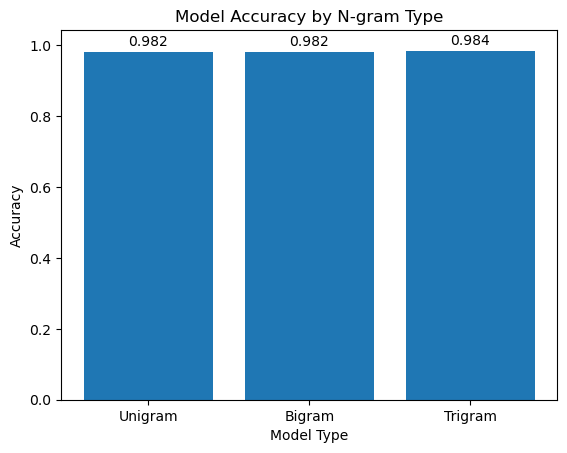

In [27]:
models = ['Unigram', 'Bigram', 'Trigram']
accuracy = [0.9815627743634767, 0.9815627743634767, 0.9841966637401229]

plt.figure()
bars = plt.bar(models, accuracy)
plt.title("Model Accuracy by N-gram Type")
plt.ylabel("Accuracy")
plt.xlabel("Model Type")
# To add lables above each bar
ymax = max(accuracy)
plt.ylim(0, ymax * 1.06)  # small headroom for labels
for bar, acc in zip(bars, accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (ymax * 0.01),
             f"{acc:.3f}", ha='center', va='bottom')
plt.show()

## Key Insights
While the trigram gives the most accurate spam vs ham filter for the emails, it is only 0.02% more accurate than either unigram and bigram.

# Error Analysis

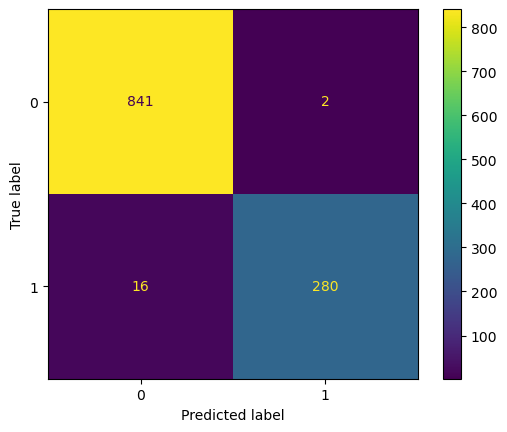

In [29]:
ConfusionMatrixDisplay.from_estimator(model, X_test_vec, y_test)
plt.show()

The above is a confusion matrix of the the model. This shows that for spam emails (1) it incorrectly said 16 (the bottom left) emails where spam when they were not, but it correctly said that 280 emails where spam when they were. This also tells us that the model correctly said that 841 emails where ham, and it only incorrectly said that 2 emails where spam when they where ham. 

# Model Interpretability

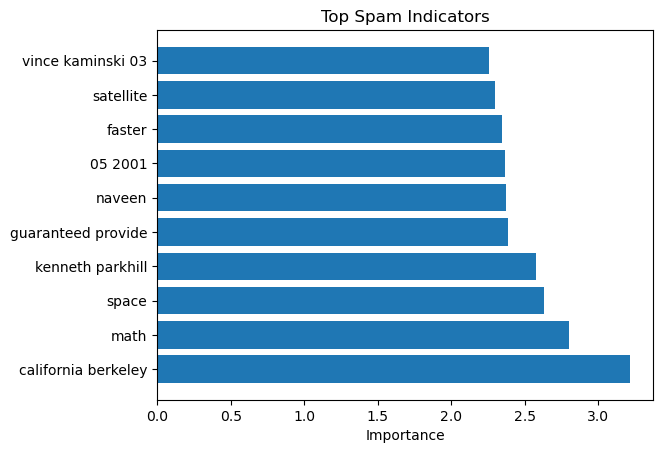

In [30]:
top_words = [word for coef, word in top_spam_words[:10]]
top_values = [abs(coef) for coef, word in top_spam_words[:10]]

plt.figure()
plt.barh(top_words, top_values)
plt.title("Top Spam Indicators")
plt.xlabel("Importance")
plt.show()